# C-GASTON Evaluation Notebook
**Sharvani Sinha — EECS 545**

This notebook loads trained C-GASTON (CONCH) model checkpoints and computes all evaluation metrics from the project spec:

1. **ARI** — Adjusted Rand Index (primary metric)
2. **NMI** — Normalized Mutual Information
3. **Isodepth-Label Correlation**
4. **Boundary Precision@50µm** — fraction of predicted boundaries within 50µm of ground truth
5. **Per-layer F1** — especially Layer 4 (target F1 ≥ 0.7)
6. **Spatial Coherence Score** — compactness of predicted domains

Outputs a summary table + visualizations saved to Drive.

## Step 0: Install Dependencies

In [1]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

pip('anndata', 'scanpy', 'scipy', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'kneed')
pip('gaston-spatial')
print('Done.')

Done.


## Step 1: Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


## Step 2: Imports

In [3]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import scipy.sparse as sp
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    f1_score,
    confusion_matrix
)
from gaston import dp_related

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


## Step 3: Configuration

**Edit the paths below to match your Drive structure.**
Point `RESULTS_DIR` at wherever the training notebook saved `cgaston_best.pt`, `cgaston_isodepth.npy`, and `cgaston_labels.npy`.

In [4]:
# ── EDIT THESE PATHS (based on where you have your model checkpoints saved) ──────────────────────────────────────────
BASE_DIR        = '/content/drive/MyDrive/EECS 545 Project'
# GLMPCA_DIR      = '/content/drive/MyDrive/EECS545_glmpca_results'
RESULTS_DIR     = '/content/drive/MyDrive/C_GASTON_UNI'
EVAL_OUTPUT_DIR = '/content/drive/MyDrive/C_GASTON_UNI_eval'
HE_BASE_DIR     = f'{BASE_DIR}/DLPFC_Datasets(raw data)'
SAMPLE1_DIR     = f'{HE_BASE_DIR}/Sample1/h5ad_cordintae_data'
SAMPLE3_DIR     = f'{HE_BASE_DIR}/Sample3/h5ad_cordinate_data'
# ─────────────────────────────────────────────────────────────

os.makedirs(EVAL_OUTPUT_DIR, exist_ok=True)

ALL_SLICES = ['151507', '151508', '151509', '151510',
              '151673', '151674', '151675', '151676']

SLICE_DATA_DIRS = {
    '151507': SAMPLE1_DIR, '151508': SAMPLE1_DIR,
    '151509': SAMPLE1_DIR, '151510': SAMPLE1_DIR,
    '151673': SAMPLE3_DIR, '151674': SAMPLE3_DIR,
    '151675': SAMPLE3_DIR, '151676': SAMPLE3_DIR,
}

LABEL_TO_INT = {'L1': 0, 'L2': 1, 'L3': 2, 'L4': 3, 'L5': 4, 'L6': 5, 'WM': 6}
INT_TO_LABEL = {v: k for k, v in LABEL_TO_INT.items()}
NUM_LAYERS   = 7

# Model architecture — must match training notebook
NUM_DIMS        = 14
EMBEDDING_DIM   = 128
ISODEPTH_ARCH   = [20, 20]
EXPRESSION_ARCH = [20, 20]

# Visium physical parameters (10x Genomics spec)
SPOT_DIAMETER_UM      = 55.0   # µm
INTER_SPOT_SPACING_UM = 100.0  # µm center-to-center
BOUNDARY_THRESHOLD_UM = 50.0   # Boundary Precision threshold from proposal

print('Configuration loaded.')

Configuration loaded.


## Step 4: Model Definition


In [ ]:
class CGASTON(nn.Module):
    def __init__(self, K, D_v, D=128, isodepth_arch=[20,20], expression_arch=[20,20]):
        super().__init__()
        self.K = K
        self.D = D
        enc_layers = []
        dims = [2] + isodepth_arch + [1]
        for i in range(len(dims) - 1):
            enc_layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                enc_layers.append(nn.ReLU())
        self.encoder = nn.Sequential(*enc_layers)

        dec_layers = []
        dims = [1] + expression_arch + [K]
        for i in range(len(dims) - 1):
            dec_layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                dec_layers.append(nn.ReLU())
        self.decoder = nn.Sequential(*dec_layers)

        self.mol_projection = nn.Linear(1 + K, D)
        self.vis_projection = nn.Sequential(
            nn.Linear(D_v, 512), nn.ReLU(), nn.LayerNorm(512), nn.Linear(512, D),
        )

    def encode_isodepth(self, S):
        return self.encoder(S)

    def molecular_embedding(self, S):
        d = self.encode_isodepth(S)
        z_hat = self.decoder(d)
        return self.mol_projection(torch.cat([d, z_hat], dim=1)), d, z_hat

    def forward(self, S, v):
        z_m, d, z_hat = self.molecular_embedding(S)
        z_v = self.vis_projection(v)
        return z_m, z_v, d, z_hat

class CGASTONWrapper:
    """Adapter so dp_related.get_isodepth_labels() can call the model."""
    def __init__(self, model):
        self.spatial_embedding  = model.encoder
        self.expression_function = model.decoder

print('Model classes defined.')

Model classes defined.


## Step 5: Helper — z-score normalization (same as training)

In [ ]:
def load_rescale_input_data(S, A):
    S_norm = (S - S.mean(axis=0)) / (S.std(axis=0) + 1e-8)
    A_norm = (A - A.mean(axis=0)) / (A.std(axis=0) + 1e-8)
    return (torch.tensor(S_norm, dtype=torch.float32),
            torch.tensor(A_norm, dtype=torch.float32))

print('Helper defined.')

Helper defined.


## Step 6: Load Data + Trained Models

In [ ]:

# ResNet-50 → 2048  |  ViT-B/16 → 768  |  UNI → 1024  |  CONCH → 512
D_v = 512   # <-- CHANGE THIS if using a different backbone
# ─────────────────────────────────────────────────────────────

data = {}
models = {}

for sid in ALL_SLICES:
    print(f'\n--- {sid} ---')

    # Load h5ad
    adata = ad.read_h5ad(f'{SLICE_DATA_DIRS[sid]}/{sid}.h5ad')
    adata.var_names_make_unique()
    S = np.asarray(adata.obsm['spatial'])
    gt_str = adata.obs['original_domain'].astype(str).values
    gt_int = np.array([LABEL_TO_INT.get(l, -1) for l in gt_str])

    # Load GLM-PCA
    A = np.load(f'{GLMPCA_DIR}/{sid}/glmpca.npy')
    S_torch, A_torch = load_rescale_input_data(S, A)

    data[sid] = {
        'adata': adata, 'coords': S,
        'gt_labels': gt_int, 'gt_str': gt_str,
        'S_torch': S_torch, 'A_torch': A_torch,
    }

    # Load trained model
    model_path = f'{RESULTS_DIR}/{sid}/cgaston_best.pt'
    if not os.path.isfile(model_path):
        print(f'  WARNING: No checkpoint at {model_path} — skipping')
        models[sid] = None
        continue

    mdl = CGASTON(K=NUM_DIMS, D_v=D_v, D=EMBEDDING_DIM,
                  isodepth_arch=ISODEPTH_ARCH,
                  expression_arch=EXPRESSION_ARCH)
    mdl.load_state_dict(torch.load(model_path, map_location='cpu'))
    mdl.eval()
    models[sid] = mdl
    print(f'  Loaded checkpoint. Spots: {S.shape[0]}')

print('\n[OK] All slices loaded.')


--- 151507 ---
  Loaded checkpoint. Spots: 4221

--- 151508 ---
  Loaded checkpoint. Spots: 4381

--- 151509 ---
  Loaded checkpoint. Spots: 4788

--- 151510 ---
  Loaded checkpoint. Spots: 4595

--- 151673 ---
  Loaded checkpoint. Spots: 3611

--- 151674 ---
  Loaded checkpoint. Spots: 3635

--- 151675 ---
  Loaded checkpoint. Spots: 3566

--- 151676 ---
  Loaded checkpoint. Spots: 3431

[OK] All slices loaded.


## Step 7: Compute Isodepth + Domain Labels

In [ ]:
predictions = {}

for sid in ALL_SLICES:
    if models[sid] is None:
        print(f'{sid}: skipped (no model)')
        continue

    print(f'Computing isodepth for {sid}...')
    mdl = models[sid].cpu()
    wrapper = CGASTONWrapper(mdl)

    S_np = data[sid]['S_torch'].numpy()
    A_np = data[sid]['A_torch'].numpy()

    isodepth, labels = dp_related.get_isodepth_labels(
        wrapper, A_np, S_np, NUM_LAYERS, num_buckets=100
    )

    predictions[sid] = {
        'isodepth': isodepth,
        'labels':   labels.astype(int),
    }

    # Save
    save_dir = f'{EVAL_OUTPUT_DIR}/{sid}'
    os.makedirs(save_dir, exist_ok=True)
    np.save(f'{save_dir}/isodepth.npy', isodepth)
    np.save(f'{save_dir}/labels.npy',   labels)
    print(f'  Saved to {save_dir}')

print('\n[OK] Predictions computed.')

Computing isodepth for 151507...
  Saved to /content/drive/MyDrive/C_GASTON_eval_sharvani/151507
Computing isodepth for 151508...
  Saved to /content/drive/MyDrive/C_GASTON_eval_sharvani/151508
Computing isodepth for 151509...
  Saved to /content/drive/MyDrive/C_GASTON_eval_sharvani/151509
Computing isodepth for 151510...
  Saved to /content/drive/MyDrive/C_GASTON_eval_sharvani/151510
Computing isodepth for 151673...
  Saved to /content/drive/MyDrive/C_GASTON_eval_sharvani/151673
Computing isodepth for 151674...
  Saved to /content/drive/MyDrive/C_GASTON_eval_sharvani/151674
Computing isodepth for 151675...
  Saved to /content/drive/MyDrive/C_GASTON_eval_sharvani/151675
Computing isodepth for 151676...
  Saved to /content/drive/MyDrive/C_GASTON_eval_sharvani/151676

[OK] Predictions computed.


## Step 8: Core Metrics — ARI, NMI, Correlation, Per-layer F1

In [ ]:
def compute_core_metrics(gt, pred_labels, isodepth):
    """ARI, NMI, isodepth-label correlation, per-layer F1."""
    valid = gt >= 0
    gt_v, pred_v = gt[valid], pred_labels[valid]

    ari  = adjusted_rand_score(gt_v, pred_v)
    nmi  = normalized_mutual_info_score(gt_v, pred_v)

    d_norm = (isodepth - isodepth.min()) / (isodepth.max() - isodepth.min() + 1e-8)
    corr   = abs(np.corrcoef(d_norm[valid], gt_v)[0, 1])

    # Per-layer F1 (one-vs-rest)
    per_layer_f1 = f1_score(gt_v, pred_v, average=None,
                            labels=list(range(NUM_LAYERS)), zero_division=0)

    return {
        'ari':  ari,
        'nmi':  nmi,
        'corr': corr,
        'per_layer_f1': per_layer_f1,
        'macro_f1': per_layer_f1.mean(),
        'L4_f1': per_layer_f1[3],  # Layer 4 index = 3
    }

core_results = {}
for sid in ALL_SLICES:
    if sid not in predictions:
        continue
    gt  = data[sid]['gt_labels']
    m   = compute_core_metrics(gt, predictions[sid]['labels'], predictions[sid]['isodepth'])
    core_results[sid] = m
    print(f"{sid}: ARI={m['ari']:.4f}  NMI={m['nmi']:.4f}  Corr={m['corr']:.4f}  "
          f"L4-F1={m['L4_f1']:.4f}  MacroF1={m['macro_f1']:.4f}")

151507: ARI=0.4671  NMI=0.6197  Corr=0.8181  L4-F1=0.0371  MacroF1=0.3521
151508: ARI=0.4278  NMI=0.5746  Corr=0.4615  L4-F1=0.0256  MacroF1=0.2152
151509: ARI=0.3844  NMI=0.6003  Corr=0.5431  L4-F1=0.0365  MacroF1=0.2138
151510: ARI=0.3732  NMI=0.5784  Corr=0.6002  L4-F1=0.0932  MacroF1=0.2704
151673: ARI=0.6931  NMI=0.7537  Corr=0.9745  L4-F1=0.5062  MacroF1=0.7812
151674: ARI=0.5220  NMI=0.6292  Corr=0.9061  L4-F1=0.2984  MacroF1=0.5693
151675: ARI=0.4316  NMI=0.5637  Corr=0.8587  L4-F1=0.1322  MacroF1=0.5139
151676: ARI=0.5341  NMI=0.6673  Corr=0.9632  L4-F1=0.0000  MacroF1=0.4030


## Step 9: Boundary Precision@50µm

A boundary exists between two adjacent spots whose predicted labels differ.
We compute the physical distance (µm) of each predicted boundary to the nearest ground-truth boundary,
and report the fraction within 50µm.

In [ ]:
from scipy.spatial import cKDTree

def get_boundary_spots(coords, labels, spacing_um=100.0, neighbor_threshold=1.5):
    """
    Find spots that sit on a domain boundary:
    a spot is a boundary spot if any of its spatial neighbors has a different label.
    Uses raw pixel coords — caller converts to µm via scale factor.
    """
    tree = cKDTree(coords)
    # neighbor distance in pixel units ~ spacing_um pixels (coords are pixel-scale)
    radius = np.median(np.diff(np.sort(np.unique(coords[:, 0])))) * neighbor_threshold
    boundary_mask = np.zeros(len(coords), dtype=bool)
    for i, (c, lbl) in enumerate(zip(coords, labels)):
        idxs = tree.query_ball_point(c, r=radius)
        idxs = [j for j in idxs if j != i]
        if any(labels[j] != lbl for j in idxs):
            boundary_mask[i] = True
    return boundary_mask

def boundary_precision(coords_um, gt_labels, pred_labels, threshold_um=50.0):
    """
    Boundary Precision@threshold_um:
    fraction of predicted boundary spots within threshold_um of a GT boundary spot.
    """
    gt_boundary   = get_boundary_spots(coords_um, gt_labels)
    pred_boundary = get_boundary_spots(coords_um, pred_labels)

    if gt_boundary.sum() == 0 or pred_boundary.sum() == 0:
        return 0.0, 0, 0

    gt_boundary_coords   = coords_um[gt_boundary]
    pred_boundary_coords = coords_um[pred_boundary]

    tree = cKDTree(gt_boundary_coords)
    dists, _ = tree.query(pred_boundary_coords, k=1)
    precision = (dists <= threshold_um).mean()

    return precision, pred_boundary.sum(), gt_boundary.sum()

# Compute boundary precision for each slice
# We use the raw spatial coords (pixel) and scale to µm using Visium specs:
# inter-spot spacing = 100µm, so µm = pixels * (100 / median_pixel_spacing)
boundary_results = {}
for sid in ALL_SLICES:
    if sid not in predictions:
        continue
    coords  = data[sid]['coords'].astype(float)
    gt      = data[sid]['gt_labels']
    pred    = predictions[sid]['labels']

    # Estimate pixel spacing and convert to µm
    unique_x = np.unique(coords[:, 0])
    px_spacing = np.median(np.diff(np.sort(unique_x)))
    scale_um_per_px = INTER_SPOT_SPACING_UM / px_spacing
    coords_um = coords * scale_um_per_px

    valid = gt >= 0
    bp, n_pred_b, n_gt_b = boundary_precision(
        coords_um[valid], gt[valid], pred[valid], BOUNDARY_THRESHOLD_UM
    )
    boundary_results[sid] = {
        'boundary_precision_50um': bp,
        'n_pred_boundaries': int(n_pred_b),
        'n_gt_boundaries':   int(n_gt_b),
    }
    print(f"{sid}: BoundaryPrec@50µm={bp:.4f}  "
          f"(pred_boundary_spots={n_pred_b}, gt_boundary_spots={n_gt_b})")

151507: BoundaryPrec@50µm=0.1806  (pred_boundary_spots=764, gt_boundary_spots=952)
151508: BoundaryPrec@50µm=0.4408  (pred_boundary_spots=676, gt_boundary_spots=930)
151509: BoundaryPrec@50µm=0.3425  (pred_boundary_spots=870, gt_boundary_spots=1021)
151510: BoundaryPrec@50µm=0.3972  (pred_boundary_spots=798, gt_boundary_spots=1006)
151673: BoundaryPrec@50µm=0.4928  (pred_boundary_spots=832, gt_boundary_spots=859)
151674: BoundaryPrec@50µm=0.3887  (pred_boundary_spots=705, gt_boundary_spots=876)
151675: BoundaryPrec@50µm=0.4378  (pred_boundary_spots=571, gt_boundary_spots=891)
151676: BoundaryPrec@50µm=0.3164  (pred_boundary_spots=730, gt_boundary_spots=857)


## Step 10: Spatial Coherence Score

From the proposal: `(1/Q) * sum_p [ (1/|R_p|) * sum_{i,j in R_p} ||c_i - c_j||_2 ]`

Lower = more compact predicted domains.

In [ ]:
def spatial_coherence(coords, labels, Q=7):
    """
    Spatial coherence score from the proposal.
    Lower is better (more compact domains).
    """
    total = 0.0
    counted = 0
    for p in range(Q):
        mask = labels == p
        if mask.sum() < 2:
            continue
        region_coords = coords[mask]
        # Mean pairwise distance (more efficient than full pairwise for large regions)
        # Sample up to 500 spots to keep it tractable
        if len(region_coords) > 500:
            idx = np.random.choice(len(region_coords), 500, replace=False)
            region_coords = region_coords[idx]
        n = len(region_coords)
        # compute all pairwise distances
        diff = region_coords[:, None, :] - region_coords[None, :, :]
        dists = np.sqrt((diff ** 2).sum(-1))
        mean_dist = dists.sum() / (n * (n - 1) + 1e-8)
        total += mean_dist
        counted += 1
    return total / (counted + 1e-8)

coherence_results = {}
for sid in ALL_SLICES:
    if sid not in predictions:
        continue
    coords = data[sid]['coords'].astype(float)
    gt     = data[sid]['gt_labels']
    pred   = predictions[sid]['labels']
    valid  = gt >= 0

    sc_gt   = spatial_coherence(coords[valid], gt[valid])
    sc_pred = spatial_coherence(coords[valid], pred[valid])
    coherence_results[sid] = {'coherence_gt': sc_gt, 'coherence_pred': sc_pred}
    print(f"{sid}: SpatialCoherence (pred={sc_pred:.2f}, gt={sc_gt:.2f})")

151507: SpatialCoherence (pred=32.38, gt=36.86)
151508: SpatialCoherence (pred=27.65, gt=35.51)
151509: SpatialCoherence (pred=34.38, gt=33.87)
151510: SpatialCoherence (pred=33.91, gt=33.87)
151673: SpatialCoherence (pred=31.85, gt=33.61)
151674: SpatialCoherence (pred=27.28, gt=33.33)
151675: SpatialCoherence (pred=24.76, gt=33.88)
151676: SpatialCoherence (pred=29.02, gt=33.46)


## Step 11: Summary Table

In [ ]:
rows = []
for sid in ALL_SLICES:
    if sid not in core_results:
        continue
    m  = core_results[sid]
    b  = boundary_results.get(sid, {})
    sc = coherence_results.get(sid, {})
    rows.append({
        'Slice':               sid,
        'ARI':                 round(m['ari'],  4),
        'NMI':                 round(m['nmi'],  4),
        'Corr':                round(m['corr'], 4),
        'Macro-F1':            round(m['macro_f1'], 4),
        'L4-F1':               round(m['L4_f1'],    4),
        'BoundPrec@50µm':      round(b.get('boundary_precision_50um', float('nan')), 4),
        'SpatialCoherence':    round(sc.get('coherence_pred', float('nan')), 2),
    })

df = pd.DataFrame(rows).set_index('Slice')

# Add mean row
mean_row = df.mean(numeric_only=True).rename('MEAN')
df = pd.concat([df, mean_row.to_frame().T])

print('=' * 80)
print('C-GASTON EVALUATION SUMMARY')
print('=' * 80)
print(df.to_string(float_format='{:.4f}'.format, na_rep='—'))
print('=' * 80)

# Success criteria check
mean_ari = df.loc['MEAN', 'ARI']
mean_L4  = df.loc['MEAN', 'L4-F1']
print(f"\nSuccess criteria check:")
print(f"  Mean ARI = {mean_ari:.4f}  (target: ≥ GASTON + 0.15)")
print(f"  Mean L4-F1 = {mean_L4:.4f}  (target: ≥ 0.70, currently ~0.50 for GASTON)")

# Save CSV
csv_path = f'{EVAL_OUTPUT_DIR}/eval_summary.csv'
df.to_csv(csv_path)
print(f"\nSaved: {csv_path}")

C-GASTON EVALUATION SUMMARY
          ARI    NMI   Corr  Macro-F1  L4-F1  BoundPrec@50µm  SpatialCoherence
151507 0.4671 0.6197 0.8181    0.3521 0.0371          0.1806           32.3800
151508 0.4278 0.5746 0.4615    0.2152 0.0256          0.4408           27.6500
151509 0.3844 0.6003 0.5431    0.2138 0.0365          0.3425           34.3800
151510 0.3732 0.5784 0.6002    0.2704 0.0932          0.3972           33.9100
151673 0.6931 0.7537 0.9745    0.7812 0.5062          0.4928           31.8500
151674 0.5220 0.6292 0.9061    0.5693 0.2984          0.3887           27.2800
151675 0.4316 0.5637 0.8587    0.5139 0.1322          0.4378           24.7600
151676 0.5341 0.6673 0.9632    0.4030 0.0000          0.3164           29.0200
MEAN   0.4792 0.6234 0.7657    0.4149 0.1411          0.3746           30.1537

Success criteria check:
  Mean ARI = 0.4792  (target: ≥ GASTON + 0.15)
  Mean L4-F1 = 0.1411  (target: ≥ 0.70, currently ~0.50 for GASTON)

Saved: /content/drive/MyDrive/C_GASTON_ev

## Step 12: Visualizations

In [ ]:
# ── 12a: Spatial domain maps (GT vs Predicted) for each slice ──
LAYER_COLORS = [
    '#e41a1c', '#ff7f00', '#4daf4a', '#984ea3',
    '#377eb8', '#a65628', '#f781bf'
]
LAYER_CMAP = plt.cm.colors.ListedColormap(LAYER_COLORS) if hasattr(plt.cm, 'colors') else None

for sid in ALL_SLICES:
    if sid not in predictions:
        continue

    coords = data[sid]['coords']
    gt     = data[sid]['gt_labels']
    pred   = predictions[sid]['labels']
    iso    = predictions[sid]['isodepth']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Ground truth
    sc0 = axes[0].scatter(coords[:, 0], coords[:, 1], c=gt,
                          cmap='tab10', vmin=0, vmax=6, s=4, rasterized=True)
    axes[0].set_title(f'{sid} — Ground Truth', fontsize=11)
    axes[0].invert_yaxis()
    axes[0].set_aspect('equal')
    axes[0].axis('off')

    # Predicted labels
    sc1 = axes[1].scatter(coords[:, 0], coords[:, 1], c=pred,
                          cmap='tab10', vmin=0, vmax=6, s=4, rasterized=True)
    m = core_results.get(sid, {})
    axes[1].set_title(f'C-GASTON Predicted\nARI={m.get("ari",0):.3f}  L4-F1={m.get("L4_f1",0):.3f}',
                      fontsize=11)
    axes[1].invert_yaxis()
    axes[1].set_aspect('equal')
    axes[1].axis('off')

    # Isodepth (continuous)
    sc2 = axes[2].scatter(coords[:, 0], coords[:, 1], c=iso,
                          cmap='viridis', s=4, rasterized=True)
    plt.colorbar(sc2, ax=axes[2], fraction=0.03)
    axes[2].set_title('Isodepth (continuous)', fontsize=11)
    axes[2].invert_yaxis()
    axes[2].set_aspect('equal')
    axes[2].axis('off')

    # Legend
    patches = [mpatches.Patch(color=plt.cm.tab10(i/9), label=INT_TO_LABEL[i])
               for i in range(NUM_LAYERS)]
    fig.legend(handles=patches, loc='lower center', ncol=7, fontsize=8,
               bbox_to_anchor=(0.5, -0.02))

    plt.suptitle(f'Slice {sid}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    out = f'{EVAL_OUTPUT_DIR}/{sid}_spatial_map.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

Output hidden; open in https://colab.research.google.com to view.

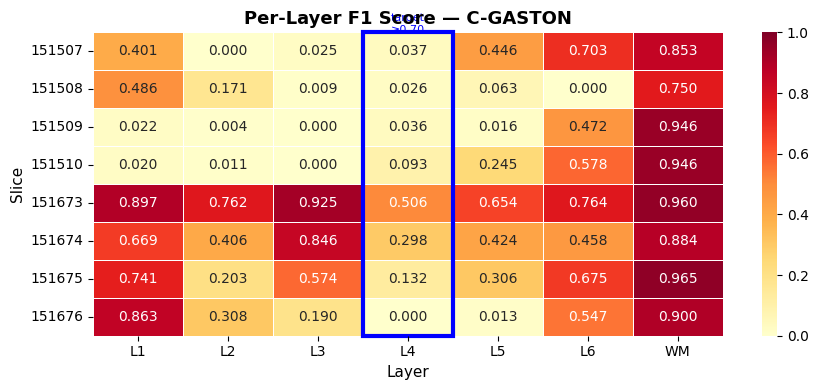

Saved: /content/drive/MyDrive/C_GASTON_eval_sharvani/per_layer_f1_heatmap.png


In [ ]:
# ── 12b: Per-layer F1 heatmap ──
layer_names = [INT_TO_LABEL[i] for i in range(NUM_LAYERS)]
f1_matrix = np.array([
    core_results[sid]['per_layer_f1']
    for sid in ALL_SLICES if sid in core_results
])
slice_names = [sid for sid in ALL_SLICES if sid in core_results]

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(f1_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=layer_names, yticklabels=slice_names,
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Per-Layer F1 Score — C-GASTON', fontsize=13, fontweight='bold')
ax.set_xlabel('Layer', fontsize=11)
ax.set_ylabel('Slice', fontsize=11)
# Highlight L4 column
ax.add_patch(plt.Rectangle((3, 0), 1, len(slice_names), fill=False,
                             edgecolor='blue', linewidth=3, clip_on=False))
ax.text(3.5, -0.5, 'target\n≥0.70', ha='center', va='top', color='blue', fontsize=8)
plt.tight_layout()
out = f'{EVAL_OUTPUT_DIR}/per_layer_f1_heatmap.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

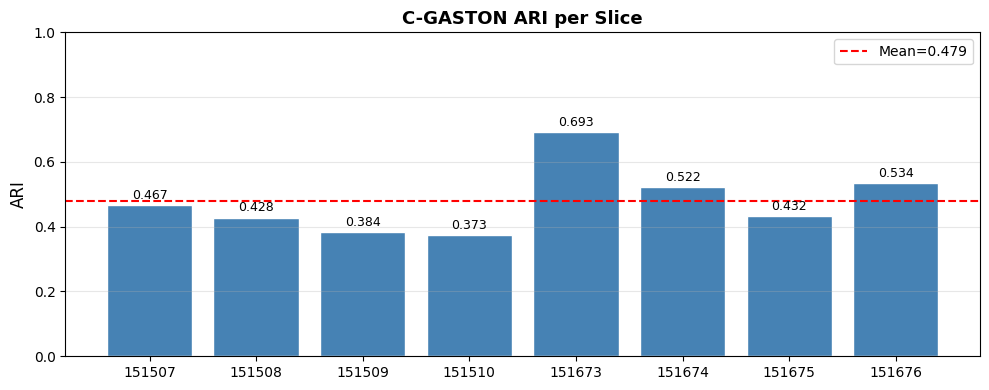

Saved: /content/drive/MyDrive/C_GASTON_eval_sharvani/ari_bar_chart.png


In [ ]:
# ── 12c: ARI bar chart per slice ──
slices = [s for s in ALL_SLICES if s in core_results]
aris   = [core_results[s]['ari'] for s in slices]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(slices, aris, color='steelblue', edgecolor='white')
ax.axhline(np.mean(aris), color='red', linestyle='--', linewidth=1.5, label=f'Mean={np.mean(aris):.3f}')
ax.set_ylabel('ARI', fontsize=12)
ax.set_title('C-GASTON ARI per Slice', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, aris):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
out = f'{EVAL_OUTPUT_DIR}/ari_bar_chart.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

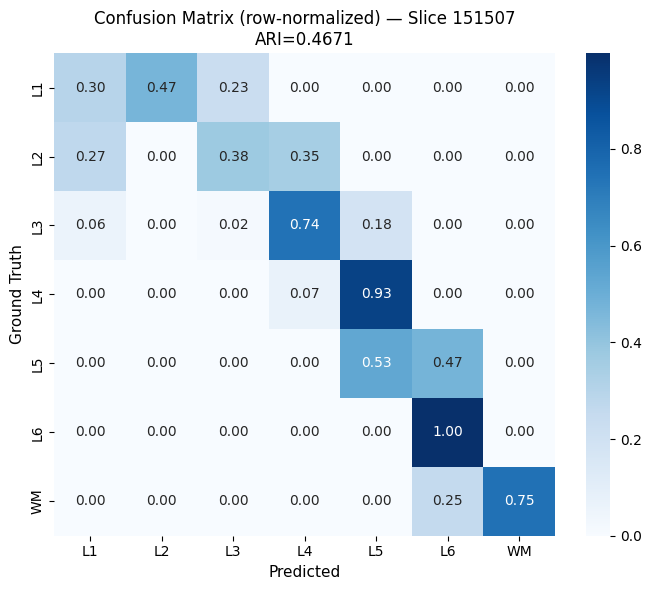

Saved: /content/drive/MyDrive/C_GASTON_eval_sharvani/151507_confusion_matrix.png


In [ ]:
# ── 12d: Confusion matrix for one representative slice ──
REP_SLICE = '151507'  # change if needed

if REP_SLICE in predictions and REP_SLICE in core_results:
    gt   = data[REP_SLICE]['gt_labels']
    pred = predictions[REP_SLICE]['labels']
    valid = gt >= 0

    cm = confusion_matrix(gt[valid], pred[valid], labels=list(range(NUM_LAYERS)))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=layer_names, yticklabels=layer_names, ax=ax)
    ax.set_title(f'Confusion Matrix (row-normalized) — Slice {REP_SLICE}\n'
                 f'ARI={core_results[REP_SLICE]["ari"]:.4f}', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Ground Truth', fontsize=11)
    plt.tight_layout()
    out = f'{EVAL_OUTPUT_DIR}/{REP_SLICE}_confusion_matrix.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

## Step 13: Final Output
Print paths to everything saved.

In [ ]:
print('=' * 60)
print('All evaluation outputs saved to:')
print(f'  {EVAL_OUTPUT_DIR}/')
print()
print('Files:')
for f in sorted(os.listdir(EVAL_OUTPUT_DIR)):
    print(f'  {f}')
print()
print('Final Summary (MEAN across slices):')
print(df.loc['MEAN'].to_string(float_format='{:.4f}'.format))
print('=' * 60)

All evaluation outputs saved to:
  /content/drive/MyDrive/C_GASTON_eval_sharvani/

Files:
  151507
  151507_confusion_matrix.png
  151507_spatial_map.png
  151508
  151508_spatial_map.png
  151509
  151509_spatial_map.png
  151510
  151510_spatial_map.png
  151673
  151673_spatial_map.png
  151674
  151674_spatial_map.png
  151675
  151675_spatial_map.png
  151676
  151676_spatial_map.png
  ari_bar_chart.png
  eval_summary.csv
  per_layer_f1_heatmap.png

Final Summary (MEAN across slices):
ARI                 0.4792
NMI                 0.6234
Corr                0.7657
Macro-F1            0.4149
L4-F1               0.1411
BoundPrec@50µm      0.3746
SpatialCoherence   30.1537


In [ ]:
# Step 14: Moran's I (spatial autocorrelation of isodepth)
!pip('libpysal', 'esda')

from libpysal.weights import KNN
from esda.moran import Moran

def compute_morans_i(coords, isodepth, k=6):
    w = KNN.from_array(coords, k=k)
    w.transform = 'r'
    return Moran(isodepth, w).I

morans = {}
for sid in ALL_SLICES:
    if sid not in predictions:
        continue
    mi = compute_morans_i(data[sid]['coords'].astype(float), predictions[sid]['isodepth'])
    morans[sid] = mi
    print(f"{sid}: Moran's I = {mi:.4f}")

mean_mi = np.mean(list(morans.values()))

/bin/bash: -c: line 1: syntax error near unexpected token `'libpysal','
/bin/bash: -c: line 1: `pip('libpysal', 'esda')'
151507: Moran's I = 0.9966
151508: Moran's I = 0.9770
151509: Moran's I = 0.9971
151510: Moran's I = 0.9975
151673: Moran's I = 0.9961
151674: Moran's I = 0.9930
151675: Moran's I = 0.9960
151676: Moran's I = 0.9967
